In [3]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [10]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "data/" if IN_COLAB else "data/asl_data/"

Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [11]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [12]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

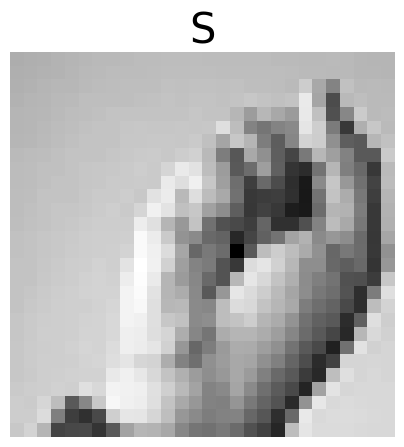

In [13]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [14]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [15]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [16]:
	
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [17]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [18]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [19]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

Training the models
Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [20]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [21]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:29<00:00,  1.46s/epoch, train_acc=0.8972, train_loss=0.2965, val_acc=0.7914, val_loss=0.8052]


In [22]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [23]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [24]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [03:47<00:00, 11.36s/epoch, train_acc=0.9969, train_loss=0.0111, val_acc=0.9571, val_loss=0.2563]


In [25]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

Reflection section

Which model is better at classifying ASL images?
El modelo que claramente mejor desempeño tiene es el CNN. Esto se ve directamente en los resultados: mientras el modelo FCNN alcanza alrededor de 79% de accuracy en validación, el CNN llega aproximadamente a 95.7%, lo cual es una mejora bastante significativa. Esto tiene mucho sentido porque las CNN están diseñadas específicamente para trabajar con imágenes, ya que pueden detectar patrones espaciales como bordes, formas y estructuras, mientras que el FCNN simplemente aplana la imagen y pierde toda esa información visual importante.

Which model was faster to train?
El modelo más rápido de entrenar fue el FCNN. En los resultados se puede ver que cada época del FCNN toma aproximadamente 1.46 segundos, mientras que el CNN tarda alrededor de 11.36 segundos por época. Esto ocurre porque el CNN tiene operaciones más complejas (como convoluciones y pooling), además de más cálculos por capa, lo que lo hace computacionalmente más costoso. En pocas palabras, el FCNN es más simple y por eso entrena más rápido.

Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?
Al comparar las curvas de aprendizaje, se puede observar que el CNN converge mucho mejor que el FCNN. El FCNN mejora al inicio, pero rápidamente se estanca y muestra una diferencia notable entre entrenamiento y validación, lo que indica que no logra generalizar tan bien. En cambio, el CNN muestra una mejora más consistente: su accuracy de entrenamiento y validación crecen de manera más alineada, y la pérdida disminuye significativamente en ambos casos. Esto indica que el modelo no solo aprende bien los datos de entrenamiento, sino que también logra generalizar mejor a datos nuevos.

How many trainable parameters does each model have?
El FCNN tiene una cantidad mucho mayor de parámetros en sus capas fully connected, especialmente en la primera capa que conecta todos los pixeles (28x28 = 784) con 512 neuronas, lo que genera cientos de miles de parámetros desde el inicio. En cambio, el CNN reduce la cantidad de parámetros en las primeras capas, ya que utiliza filtros pequeños (kernels) que se comparten a lo largo de la imagen. Aunque el CNN también tiene capas densas al final, en general es más eficiente en cómo utiliza sus parámetros para aprender patrones relevantes.

How do the models compare in terms of overfitting? Why do you think that is the case?
El FCNN presenta más overfitting que el CNN. Esto se nota porque hay una diferencia más grande entre su desempeño en entrenamiento y validación. El modelo aprende bien los datos de entrenamiento, pero no logra generalizar igual de bien. En cambio, el CNN tiene una brecha mucho menor entre ambos, lo que indica mejor generalización.
Esto pasa principalmente porque el CNN está mejor adaptado para imágenes: usa convoluciones que capturan patrones locales y reutilizan pesos, lo que reduce el riesgo de sobreajuste. Además, incluye técnicas como pooling y dropout que ayudan a regularizar el modelo. Por otro lado, el FCNN trata cada pixel de manera independiente, lo cual lo hace menos eficiente y más propenso a memorizar en lugar de aprender patrones reales.